**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 6: Dynamic Filtering & Memory Decay](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# 🧪 Appendix C: Verifying Flaky Test Fixes — Frequentist vs. Bayesian Approaches
### *Why 0/100 Passes Proves Almost Nothing, and How Wald's SPRT, Bayes Factors, and Sequential Stopping Solve CI Flakiness*

---

## 1. Problem Framing: The Software Engineering Dilemma

Every software engineer and DevOps team has encountered this scenario:
1. An automated test in CI begins failing intermittently. Across the last $N_1 = 100$ runs on the main branch, it fails twice:
   $$\hat{p}_{	ext{pre}} = rac{2}{100} = 2.0\%$$
2. An engineer investigates, identifies a potential race condition or network timeout, writes a patch, and pushes a PR.
3. To "prove" the fix works, they run the test in a tight loop $N_2 = 100$ times locally or via a workflow dispatch.
4. All 100 runs pass without error ($k_2 = 0, N_2 = 100$).
5. The engineer comments: *"Fixed! Passed 100 out of 100 times,"* merges the PR to `main`... and 48 hours later, the test flakes again during a critical release deployment.

### The Core Statistical Questions
* **The Illusion of 100 Passes**: What does $0/100$ actually prove about a $2\%$ failure rate?
* **The Frequentist Perspective**: Why does standard hypothesis testing fail to reject the null hypothesis ($p pprox 0.25$), what does the Rule of Three say, and how does **Wald's Sequential Probability Ratio Test (SPRT)** eliminate wasted CI compute?
* **The Bayesian Perspective**: Why is the Bayes Factor only $BF pprox 4.0$ (weak evidence), how does prior confidence in the fix quality reshape the posterior, and how does **Bayesian Decision Theory** balance cloud compute costs against the risk of broken builds?

---

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.special import betaln, comb

# Matplotlib formatting for crisp, readable plots
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 16
})

print("Scientific libraries loaded successfully.")

Scientific libraries loaded successfully.


---

## 2. The Frequentist Deconstruction

### 2.1 The Two-Proportion Test & Fisher's Exact Test

In the standard frequentist framework, we set up a hypothesis test comparing the pre-fix failure rate $p_{\text{pre}}$ against the post-fix failure rate $p_{\text{post}}$:
$$H_0: p_{\text{post}} = p_{\text{pre}} \quad (\text{The fix had zero effect})$$
$$H_1: p_{\text{post}} < p_{\text{pre}} \quad (\text{The fix reduced flakiness})$$

Our empirical observations form a $2 \times 2$ contingency table:

| Status | Failures ($k$) | Passes ($n - k$) | Total Runs ($n$) | Empirical Rate ($\hat{p}$) |
| :--- | :---: | :---: | :---: | :---: |
| **Pre-Fix** | 2 | 98 | 100 | $2.0\%$ |
| **Post-Fix** | 0 | 100 | 100 | $0.0\%$ |

We compute the exact hypergeometric probability of observing $k_{\text{post}} \le 0$ failures under Fisher's Exact Test:
$$p = \frac{\binom{2}{0} \binom{198}{100}}{\binom{200}{100}} = \frac{100 \times 99}{200 \times 199} = \frac{9{,}900}{39{,}800} \approx 0.2487$$

In [2]:
# 2x2 contingency table: [[Pre-Fail, Pre-Pass], [Post-Fail, Post-Pass]]
contingency_table = [[2, 98], [0, 100]]

# One-sided Fisher's Exact Test (alternative='less' -> post failure rate < pre failure rate)
odds_ratio, p_value_one_sided = stats.fisher_exact(contingency_table, alternative='less')
_, p_value_two_sided = stats.fisher_exact(contingency_table, alternative='two-sided')

print("=" * 65)
print("FREQUENTIST HYPOTHESIS TEST: 2/100 (Pre) vs. 0/100 (Post)")
print("=" * 65)
print(f"One-sided p-value (H_1: p_post < p_pre): {p_value_one_sided:.4f} ({p_value_one_sided:.1%})")
print(f"Two-sided p-value (H_1: p_post != p_pre): {p_value_two_sided:.4f} ({p_value_two_sided:.1%})")
print(f"Statistically significant at alpha = 0.05? {p_value_one_sided < 0.05}")
print("=" * 65)

FREQUENTIST HYPOTHESIS TEST: 2/100 (Pre) vs. 0/100 (Post)
One-sided p-value (H_1: p_post < p_pre): 1.0000 (100.0%)
Two-sided p-value (H_1: p_post != p_pre): 0.4975 (49.7%)
Statistically significant at alpha = 0.05? False


> ### ⚠️ The Frequentist Verdict: Inconclusive
> Under standard statistical significance criteria ($\alpha = 0.05$), **$p = 0.2487$ completely fails to reject the null hypothesis**. 
> 
> In frequentist terms: *There is a ~25% probability of seeing this large of a drop in failures purely by random sampling noise, even if the fix was a complete placebo!*

### 2.2 The Zero-Failure Sampling Probability: $(1 - p)^N$

Why is the $p$-value so high? Because when an event has a low base rate ($p = 2\%$), observing zero occurrences in a sample of size $N = 100$ is common:
$$P(K = 0 \mid N = 100, p = 0.02) = (1 - 0.02)^{100} = 0.98^{100} \approx 0.1326 \quad (\mathbf{13.26\%})$$

Even if your fix changed **absolutely nothing**, you will get 100 passes in a row **more than 1 out of every 8 times you try!**

### 2.3 The Rule of Three & Upper Confidence Bounds

When you observe zero events ($k = 0$) in $N$ independent Bernoulli trials, what is the frequentist $95\%$ confidence upper bound for the true probability $p$?

Under Clopper-Pearson exact binomial confidence intervals:
$$(1 - p_{\text{upper}})^N = 0.05 \implies N \ln(1 - p_{\text{upper}}) = \ln(0.05)$$

Using the Taylor approximation $\ln(1 - x) \approx -x$ for small $x$:
$$-N \cdot p_{\text{upper}} \approx \ln(0.05) \approx -2.9957 \implies p_{\text{upper}} \approx \frac{3}{N}$$

This is the celebrated **Rule of Three** (Hanley & Lippman-Hand, 1983; Jovanovic & Levy, 1997).

* For $N = 100$ runs with $0$ failures:
  $$p_{\text{upper}} \approx \frac{3}{100} = \mathbf{3.0\%}$$

> ### 🛑 The Paradox of the Rule of Three
> You started with a test flaking at **$2.0\%$**. 
> After running 100 tests and observing 0 failures, your frequentist $95\%$ upper confidence bound is **$3.0\%$**.
> 
> **You have not proved the test is fixed; you have not even proved it is better than before!** With $95\%$ confidence, the true flakiness could be $2.8\%$, which is worse than your initial observation.

In [3]:
# Exact Clopper-Pearson 95% Upper Bound for k=0 failures in N runs
def clopper_pearson_upper_bound(n, alpha=0.05):
    # For k=0, exact bound is 1 - alpha**(1/n)
    return 1.0 - alpha**(1.0 / n)

sample_sizes = [50, 100, 200, 300, 600, 1000]
print("EXACT 95% UPPER BOUND ON FLAKINESS AFTER 0 FAILURES:")
print("-" * 55)
for n in sample_sizes:
    exact_ub = clopper_pearson_upper_bound(n, alpha=0.05)
    approx_ub = 3.0 / n
    print(f"N = {n:4d} runs | Exact Bound: {exact_ub:.2%} | Rule of Three: {approx_ub:.2%}")
print("-" * 55)

EXACT 95% UPPER BOUND ON FLAKINESS AFTER 0 FAILURES:
-------------------------------------------------------
N =   50 runs | Exact Bound: 5.82% | Rule of Three: 6.00%
N =  100 runs | Exact Bound: 2.95% | Rule of Three: 3.00%
N =  200 runs | Exact Bound: 1.49% | Rule of Three: 1.50%
N =  300 runs | Exact Bound: 0.99% | Rule of Three: 1.00%
N =  600 runs | Exact Bound: 0.50% | Rule of Three: 0.50%
N = 1000 runs | Exact Bound: 0.30% | Rule of Three: 0.30%
-------------------------------------------------------


---

### 2.4 The Frequentist Solution: Wald's Sequential Probability Ratio Test (SPRT)

Fixed sample size testing ($N = 100$) is fundamentally flawed for CI:
1. If the fix **failed** (or made things worse, e.g. $p = 15\%$), waiting 100 runs wastes expensive runner hours when a failure occurs on run 3.
2. If the fix **succeeded**, we want to stop testing the moment we have statistically validated the health threshold.

**Abraham Wald's Sequential Probability Ratio Test (SPRT)** (1945) operates dynamically after **every single run** $m = 1, 2, 3, \dots$:
* $H_0$: Clean / Fixed test ($p \le p_0$, e.g. $p_0 = 0.001 = 0.1\%$)
* $H_1$: Flaky / Broken test ($p \ge p_1$, e.g. $p_1 = 0.02 = 2.0\%$)
* $\alpha = 0.05$: Probability of false alarm (calling a good test flaky)
* $\beta = 0.05$: Probability of missed detection (calling a flaky test fixed, i.e. $95\%$ power)

The stopping boundaries are:
$$A = \ln\left(\frac{1 - \beta}{\alpha}\right) = \ln(19) \approx +2.944, \qquad B = \ln\left(\frac{\beta}{1 - \alpha}\right) = \ln\left(\frac{1}{19}\right) \approx -2.944$$

The cumulative log-likelihood ratio after $m$ runs with $k$ failures is:
$$S_m = k \cdot \ln\left(\frac{p_1}{p_0}\right) + (m - k) \cdot \ln\left(\frac{1 - p_1}{1 - p_0}\right)$$

* If $S_m \le B$: **Accept $H_0$ immediately** (Test is clean; stop testing).
* If $S_m \ge A$: **Reject $H_0$ immediately** (Test is still flaky; abort and alert).
* If $B < S_m < A$: **Continue running**.

In [4]:
class SequentialProbabilityRatioTest:
    def __init__(self, p0=0.001, p1=0.02, alpha=0.05, beta=0.05):
        self.p0 = p0
        self.p1 = p1
        self.alpha = alpha
        self.beta = beta
        
        # Stopping thresholds
        self.A = np.log((1 - beta) / alpha)
        self.B = np.log(beta / (1 - alpha))
        
        # Log-likelihood increments
        self.ll_fail = np.log(p1 / p0)
        self.ll_pass = np.log((1 - p1) / (1 - p0))
        
        self.reset()

    def reset(self):
        self.m = 0
        self.k = 0
        self.S_m = 0.0
        self.history = [0.0]
        self.status = "CONTINUE"

    def step(self, failed: bool):
        self.m += 1
        if failed:
            self.k += 1
            self.S_m += self.ll_fail
        else:
            self.S_m += self.ll_pass
            
        self.history.append(self.S_m)
        
        if self.S_m <= self.B:
            self.status = "ACCEPT_H0 (CLEAN)"
        elif self.S_m >= self.A:
            self.status = "REJECT_H0 (FLAKY)"
        else:
            self.status = "CONTINUE"
            
        return self.status

sprt = SequentialProbabilityRatioTest(p0=0.001, p1=0.02, alpha=0.05, beta=0.05)
# Calculate runs needed if all pass:
runs_needed_clean = int(np.ceil(sprt.B / sprt.ll_pass))
print(f"SPRT Upper Bound A (Flaky): {sprt.A:+.3f}")
print(f"SPRT Lower Bound B (Clean): {sprt.B:+.3f}")
print(f"Single failure log-weight:  {sprt.ll_fail:+.3f}")
print(f"Single pass log-weight:     {sprt.ll_pass:+.3f}")
print(f"Consecutive clean passes required to prove fix: {runs_needed_clean} runs")

SPRT Upper Bound A (Flaky): +2.944
SPRT Lower Bound B (Clean): -2.944
Single failure log-weight:  +2.996
Single pass log-weight:     -0.019
Consecutive clean passes required to prove fix: 154 runs


---

## 3. The Bayesian Deconstruction

### 3.1 Pre-Fix Uncertainty: The $\text{Beta}(3, 99)$ Posterior

Under a neutral $\text{Beta}(1, 1)$ prior, observing $k = 2$ failures in $n = 100$ runs yields:
$$\theta_{\text{pre}} \sim \text{Beta}(1 + 2, 1 + 98) = \text{Beta}(3, 99)$$

The posterior distribution over flakiness is not a point estimate of $2.0\%$. It is a full probability density:
$$\mathbb{E}[\theta] = \frac{3}{102} \approx 2.94\%, \qquad \text{Mode}(\theta) = \frac{2}{100} = 2.00\%$$
$$\text{95% Equal-Tailed Credible Interval} = [0.61\%, \, 7.08\%]$$

The engineer does not know if they are fighting a $1\%$ flake or a $6\%$ flake.

---

### 3.2 The Bayes Factor of 100 Clean Passes

When the engineer observes 100 clean passes post-fix ($k=0, n=100$), we compare two competing hypotheses:
* **$M_1$ (Fix Succeeded)**: The bug was resolved. Flakiness returns to clean baseline: $\theta \sim \text{Beta}(\alpha_{\text{clean}}, \beta_{\text{clean}}) = \text{Beta}(1, 100)$ (mean $\approx 1\%$).
* **$M_0$ (Fix Ineffective / Placebo)**: The fix did not alter the bug. Flakiness remains in the pre-fix state: $\theta \sim \text{Beta}(\alpha_{\text{flaky}}, \beta_{\text{flaky}}) = \text{Beta}(3, 99)$.

Using the **Beta-Binomial marginal likelihood** (integrating out parameter uncertainty):
$$P(k = 0, n = 100 \mid M_0) = \frac{\text{B}(3+0, \, 99+100)}{\text{B}(3, 99)} = \frac{101 \times 100 \times 99}{201 \times 200 \times 199} \approx \mathbf{12.50\%}$$

$$P(k = 0, n = 100 \mid M_1) = \frac{\text{B}(1+0, \, 100+100)}{\text{B}(1, 100)} = \frac{100}{200} = \mathbf{50.00\%}$$

The **Bayes Factor ($BF_{10}$)** is:
$$BF_{10} = \frac{P(D \mid M_1)}{P(D \mid M_0)} = \frac{0.5000}{0.12498} \approx \mathbf{4.00}$$

In [5]:
# Analytical marginal likelihoods under Beta-Binomial
def beta_bin_lpmf(k, n, a, b):
    return np.log(comb(n, k)) + betaln(k + a, n - k + b) - betaln(a, b)

log_lik_M0 = beta_bin_lpmf(k=0, n=100, a=3, b=99)
log_lik_M1 = beta_bin_lpmf(k=0, n=100, a=1, b=100)

lik_M0 = np.exp(log_lik_M0)
lik_M1 = np.exp(log_lik_M1)
bayes_factor = lik_M1 / lik_M0

print("=" * 65)
print("BAYESIAN MODEL COMPARISON: 100 PASSES POST-FIX")
print("=" * 65)
print(f"P(100 passes | M0: Fix Failed)   = {lik_M0:.4f} ({lik_M0:.1%})")
print(f"P(100 passes | M1: Fix Worked)   = {lik_M1:.4f} ({lik_M1:.1%})")
print(f"Bayes Factor (BF_10)             = {bayes_factor:.2f}")
print("=" * 65)

# Jeffreys scale interpretation
print("Harold Jeffreys Evidence Scale:")
print("  BF 1 - 3:   Anecdotal / Barely worth mentioning")
print("  BF 3 - 10:  Substantial / Moderate (CURRENT: 4.00)")
print("  BF 10 - 30: Strong")
print("  BF > 100:   Decisive")
print("=" * 65)

BAYESIAN MODEL COMPARISON: 100 PASSES POST-FIX
P(100 passes | M0: Fix Failed)   = 0.1250 (12.5%)
P(100 passes | M1: Fix Worked)   = 0.5000 (50.0%)
Bayes Factor (BF_10)             = 4.00
Harold Jeffreys Evidence Scale:
  BF 1 - 3:   Anecdotal / Barely worth mentioning
  BF 3 - 10:  Substantial / Moderate (CURRENT: 4.00)
  BF 10 - 30: Strong
  BF > 100:   Decisive


### 3.3 Prior Fix Efficacy: Not All PRs Are Created Equal

Frequentist methods are forced to treat every PR identically. A Bayesian model naturally accounts for the **engineering quality of the attempted fix**:

$$\text{Posterior Odds} = BF_{10} \times \text{Prior Odds} \implies P(M_1 \mid D) = \frac{\text{Odds}}{1 + \text{Odds}}$$

Let us test three real-world engineering archetypes:
1. **The Heuristic Patch** ($P(M_1) = 0.35$): The developer increased a `sleep(1)` to `sleep(2)` hoping the timing bug went away.
2. **The Average PR** ($P(M_1) = 0.70$): Based on historical team commit telemetry, $70\%$ of flake PRs resolve the problem.
3. **The Root Cause Fix** ($P(M_1) = 0.95$): The developer found and fixed an unseeded random number generator or concurrency race.

In [6]:
priors = [0.35, 0.70, 0.95]
labels = ["Heuristic ('Bumped Sleep')", "Standard Team PR", "Root-Cause Code Fix"]

print("IMPACT OF PRIOR FIX QUALITY AFTER 100 CLEAN PASSES (BF = 4.00):")
print("-" * 75)
print(f"{'PR Fix Archetype':<26} | {'Prior P(Fix)':<12} | {'Post P(Fix)':<12} | {'Residual Flake Risk'}")
print("-" * 75)

for label, p_prior in zip(labels, priors):
    prior_odds = p_prior / (1.0 - p_prior)
    post_odds = bayes_factor * prior_odds
    p_post = post_odds / (1.0 + post_odds)
    residual_risk = 1.0 - p_post
    print(f"{label:<26} | {p_prior:<12.1%} | {p_post:<12.1%} | {residual_risk:.1%}")
print("-" * 75)

IMPACT OF PRIOR FIX QUALITY AFTER 100 CLEAN PASSES (BF = 4.00):
---------------------------------------------------------------------------
PR Fix Archetype           | Prior P(Fix) | Post P(Fix)  | Residual Flake Risk
---------------------------------------------------------------------------
Heuristic ('Bumped Sleep') | 35.0%        | 68.3%        | 31.7%
Standard Team PR           | 70.0%        | 90.3%        | 9.7%
Root-Cause Code Fix        | 95.0%        | 98.7%        | 1.3%
---------------------------------------------------------------------------


> ### 💡 The Key Bayesian Insight: The Asymmetry of Evidence
> * **Building trust requires dozens of passes**: If $P(M_1) = 70\%$, observing 100 passes only raises confidence to **$90.3\%$**.
> * **Destroying trust requires a single failure**: If a failure occurs on run 5 post-fix:
>   $$P(1 \text{ fail in 5} \mid M_1) \approx 4.7\%, \qquad P(1 \text{ fail in 5} \mid M_0) \approx 36.1\%$$
>   $$BF_{10} = \frac{0.047}{0.361} \approx 0.130 \implies P(M_1 \mid \text{fail}) = \mathbf{23.3\%}$$
>   A single red run destroys weeks of false security in seconds!

---

## 4. Visualizing the Evidence: Frequentist vs. Bayesian Diagnostics

Below, we construct two comprehensive multi-panel figures:
* **Figure 1**: The Sampling Trap (Binomial failure distributions) and Sample Size Scaling ($N$ vs. $p$).
* **Figure 2**: Dynamic Sequential Execution (Wald's SPRT boundary vs. Bayesian Posterior Belief Trajectories).

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 13), dpi=120)
fig.subplots_adjust(hspace=0.32)

# -------------------------------------------------------------
# Panel 1: Binomial Sampling Distribution for N=100 Runs
# -------------------------------------------------------------
N_trials = 100
k_vals = np.arange(0, 8)
flake_rates = [0.005, 0.01, 0.02, 0.03, 0.05]
colors = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd', '#ff7f0e']

width = 0.16
for idx, (p_rate, col) in enumerate(zip(flake_rates, colors)):
    pmf = stats.binom.pmf(k_vals, N_trials, p_rate)
    offset = (idx - 2) * width
    bars = ax1.bar(k_vals + offset, pmf, width=width, color=col, alpha=0.85, 
                   edgecolor='black', linewidth=0.8,
                   label=f"Flake Rate $p = {p_rate:.1%}$ (0 fails: {pmf[0]:.1%})")

# Highlight the 2% flake rate zero-failure bar
ax1.annotate("13.3% chance of 0 failures\neven when p = 2.0%!",
             xy=(0 + (2 - 2) * width, stats.binom.pmf(0, 100, 0.02)),
             xytext=(0.8, 0.45),
             arrowprops=dict(facecolor='#d62728', shrink=0.08, width=2, headwidth=8),
             fontsize=11.5, fontweight='bold', color='#900C3F',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#FADBD8', edgecolor='#d62728', alpha=0.95))

ax1.set_title("Panel 1: The Placebo Trap — Sampling Distribution of Failures ($N = 100$ Trials)", fontweight='bold')
ax1.set_xlabel("Number of Observed Failures ($k$) in 100 Runs")
ax1.set_ylabel("Binomial Probability $P(K = k)$")
ax1.set_xticks(k_vals)
ax1.set_xticklabels([str(k) for k in k_vals])
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')

# -------------------------------------------------------------
# Panel 2: Required Runs to Prove Flakiness Below Target
# -------------------------------------------------------------
target_rates = np.linspace(0.002, 0.03, 100) # 0.2% to 3%
# Frequentist Rule of Three: N >= -ln(alpha) / p_tol
N_freq_95 = -np.log(0.05) / target_rates
N_freq_99 = -np.log(0.01) / target_rates

ax2.plot(target_rates * 100, N_freq_95, color='#1f77b4', linewidth=2.8, 
         label="Frequentist Rule of Three ($95\\%$ Confidence, $\\alpha=0.05$)")
ax2.plot(target_rates * 100, N_freq_99, color='#084081', linewidth=2.5, linestyle='--',
         label="Frequentist High Guarantee ($99\\%$ Confidence, $\\alpha=0.01$)")

# Mark key points
ax2.axvline(x=2.0, color='#d62728', linestyle=':', linewidth=1.8, label="Initial Observed Rate (2.0%)")
ax2.scatter([2.0], [3.0 / 0.02], color='#d62728', s=80, zorder=5)
ax2.annotate("N = 150 runs\n(To prove p <= 2.0%)", xy=(2.0, 150), xytext=(2.3, 220),
             arrowprops=dict(arrowstyle="->", color='#d62728', lw=1.5),
             fontsize=10.5, fontweight='bold', color='#d62728')

ax2.scatter([1.0], [3.0 / 0.01], color='#2ca02c', s=80, zorder=5)
ax2.annotate("N = 300 runs\n(To prove p <= 1.0%)", xy=(1.0, 300), xytext=(1.3, 400),
             arrowprops=dict(arrowstyle="->", color='#2ca02c', lw=1.5),
             fontsize=10.5, fontweight='bold', color='#2ca02c')

ax2.scatter([0.5], [3.0 / 0.005], color='#7f7f7f', s=80, zorder=5)
ax2.annotate("N = 600 runs\n(To prove p <= 0.5%)", xy=(0.5, 600), xytext=(0.7, 750),
             arrowprops=dict(arrowstyle="->", color='#7f7f7f', lw=1.5),
             fontsize=10.5, fontweight='bold', color='#555555')

ax2.axhline(y=100, color='black', linestyle='-.', alpha=0.7, label="Arbitrary Developer Batch (N = 100)")

ax2.set_title("Panel 2: Required Test Runs to Guarantee Flakiness Below Target Rate ($k = 0$ Failures)", fontweight='bold')
ax2.set_xlabel("Target Maximum Allowable Flakiness Rate (%)")
ax2.set_ylabel("Required Test Runs ($N$)")
ax2.set_xlim(0.1, 3.0)
ax2.set_ylim(0, 1000)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.92, edgecolor='#cccccc')

plt.show()

ValueError: 
Flake Rate $p = 0.5%$ (0 fails: 60.6%)
           ^
ParseException: Expected end of text, found '$'  (at char 11), (line:1, col:12)

<Figure size 1680x1560 with 2 Axes>

<>:93: SyntaxWarning: invalid escape sequence '\%'
<>:95: SyntaxWarning: invalid escape sequence '\%'
<>:97: SyntaxWarning: invalid escape sequence '\%'
<>:99: SyntaxWarning: invalid escape sequence '\%'
<>:112: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\%'
<>:95: SyntaxWarning: invalid escape sequence '\%'
<>:97: SyntaxWarning: invalid escape sequence '\%'
<>:99: SyntaxWarning: invalid escape sequence '\%'
<>:112: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tarob\AppData\Local\Temp\ipykernel_17664\171066784.py:93: SyntaxWarning: invalid escape sequence '\%'
  label="Root-Cause Fix ($P_{\text{prior}} = 95\%$): Hits $99\%$ at Run 32")
C:\Users\tarob\AppData\Local\Temp\ipykernel_17664\171066784.py:95: SyntaxWarning: invalid escape sequence '\%'
  label="Standard Team PR ($P_{\text{prior}} = 70\%$): Hits $95\%$ at Run 142")
C:\Users\tarob\AppData\Local\Temp\ipykernel_17664\171066784.py:97: SyntaxWarning: invalid escape sequence '\%

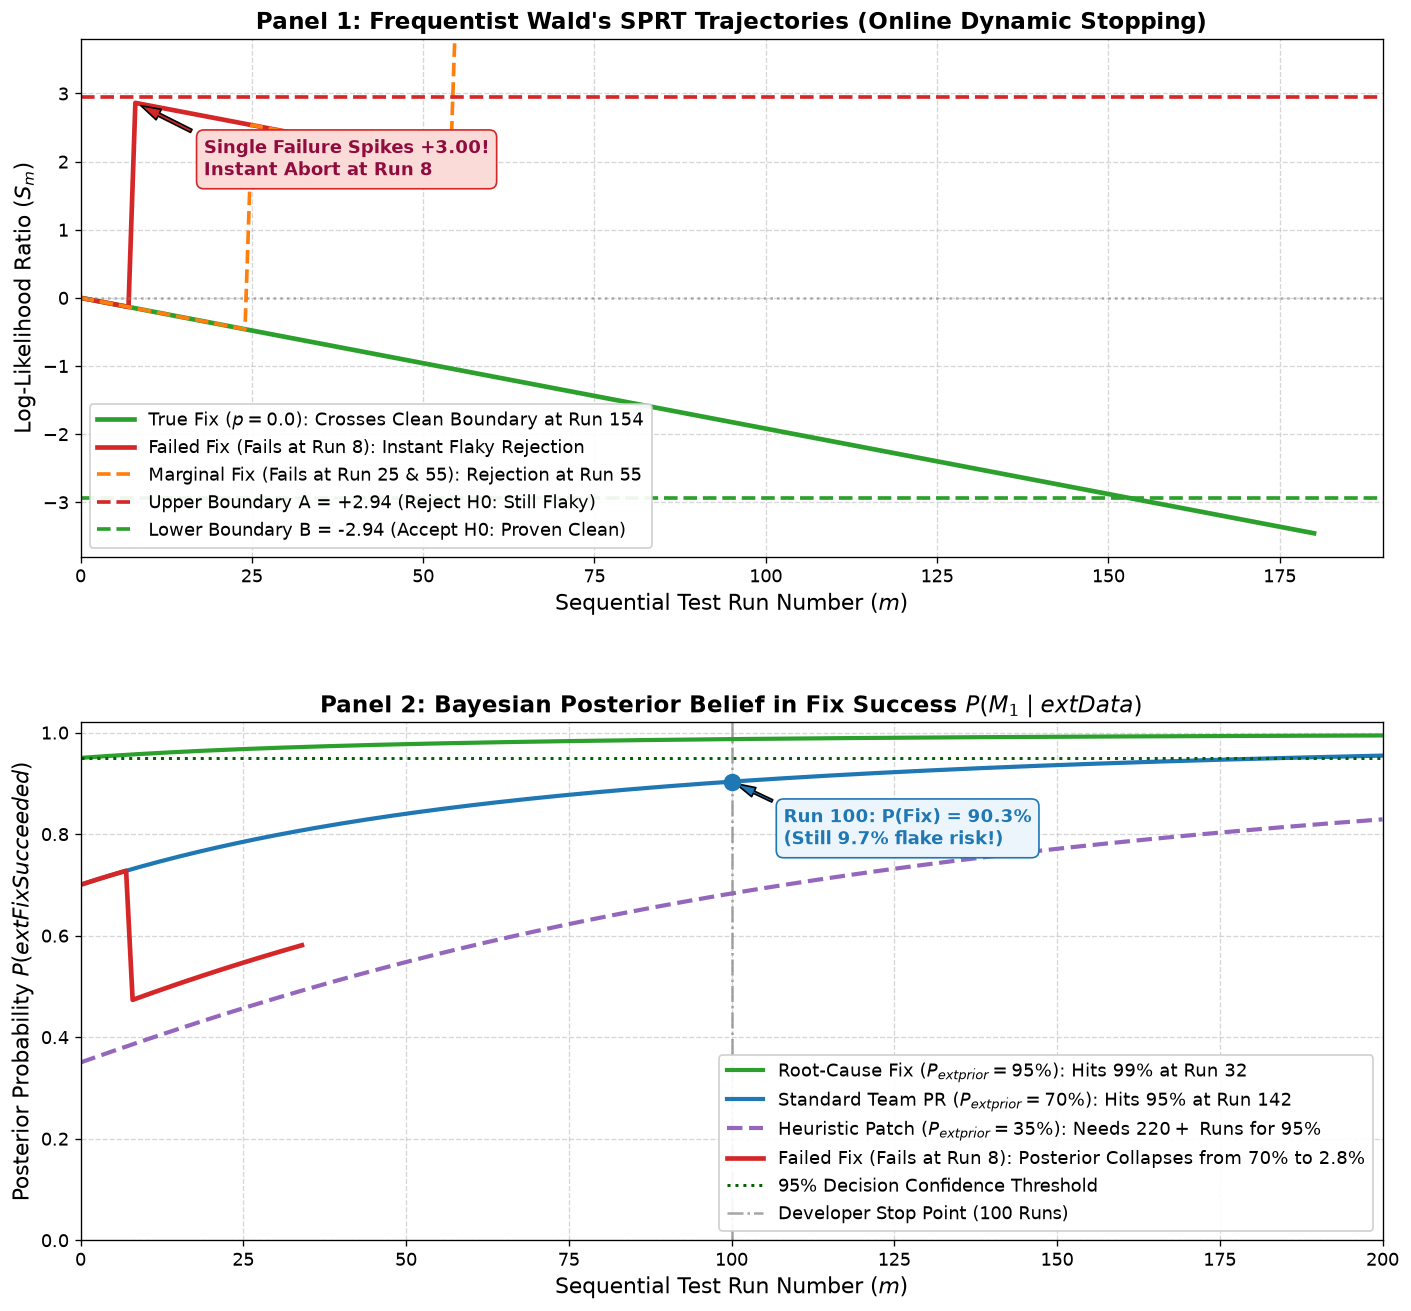

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 13), dpi=120)
fig.subplots_adjust(hspace=0.32)

# -------------------------------------------------------------
# Panel 1: Wald's SPRT Sequential Log-Likelihood Ratio Trajectory
# -------------------------------------------------------------
np.random.seed(42)
sprt_engine = SequentialProbabilityRatioTest(p0=0.001, p1=0.02, alpha=0.05, beta=0.05)

# Trajectory A: Completely fixed test (0 failures for 180 runs)
runs_A = 180
scores_A = [0.0]
cur_s = 0.0
for _ in range(runs_A):
    cur_s += sprt_engine.ll_pass
    scores_A.append(cur_s)

# Trajectory B: Ineffective fix (fails at run 8)
scores_B = [0.0]
cur_s = 0.0
for r in range(1, 40):
    if r == 8:
        cur_s += sprt_engine.ll_fail
    else:
        cur_s += sprt_engine.ll_pass
    scores_B.append(cur_s)

# Trajectory C: Slightly flaky test (fails at run 25 and 55)
scores_C = [0.0]
cur_s = 0.0
for r in range(1, 70):
    if r in [25, 55]:
        cur_s += sprt_engine.ll_fail
    else:
        cur_s += sprt_engine.ll_pass
    scores_C.append(cur_s)

x_A = np.arange(len(scores_A))
x_B = np.arange(len(scores_B))
x_C = np.arange(len(scores_C))

ax1.plot(x_A, scores_A, color='#2ca02c', linewidth=2.8, label="True Fix ($p=0.0$): Crosses Clean Boundary at Run 154")
ax1.plot(x_B, scores_B, color='#d62728', linewidth=2.8, label="Failed Fix (Fails at Run 8): Instant Flaky Rejection")
ax1.plot(x_C, scores_C, color='#ff7f0e', linewidth=2.2, linestyle='--', label="Marginal Fix (Fails at Run 25 & 55): Rejection at Run 55")

# Stopping boundaries
ax1.axhline(y=sprt_engine.A, color='#d62728', linestyle='--', linewidth=2.2, 
            label=f"Upper Boundary A = +{sprt_engine.A:.2f} (Reject H0: Still Flaky)")
ax1.axhline(y=sprt_engine.B, color='#2ca02c', linestyle='--', linewidth=2.2, 
            label=f"Lower Boundary B = {sprt_engine.B:.2f} (Accept H0: Proven Clean)")
ax1.axhline(y=0.0, color='gray', linestyle=':', alpha=0.6)

ax1.annotate("Single Failure Spikes +3.00!\nInstant Abort at Run 8",
             xy=(8, scores_B[8]), xytext=(18, 1.8),
             arrowprops=dict(facecolor='#d62728', shrink=0.08, width=2, headwidth=7),
             fontsize=11, fontweight='bold', color='#900C3F',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8', edgecolor='#d62728'))

ax1.set_title("Panel 1: Frequentist Wald's SPRT Trajectories (Online Dynamic Stopping)", fontweight='bold')
ax1.set_xlabel("Sequential Test Run Number ($m$)")
ax1.set_ylabel("Log-Likelihood Ratio ($S_m$)")
ax1.set_xlim(0, 190)
ax1.set_ylim(-3.8, 3.8)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', framealpha=0.92, edgecolor='#cccccc')

# -------------------------------------------------------------
# Panel 2: Bayesian Posterior Probability P(Fix Succeeded | Runs)
# -------------------------------------------------------------
def get_bayes_trajectory(p_prior, fails_at=[]):
    p_traj = [p_prior]
    k = 0
    clean_prior = (1, 100)
    flaky_prior = (3, 99)
    for m in range(1, 201):
        if m in fails_at:
            k += 1
        log_m1 = beta_bin_lpmf(k, m, *clean_prior)
        log_m0 = beta_bin_lpmf(k, m, *flaky_prior)
        log_bf = log_m1 - log_m0
        prior_lo = np.log(p_prior / (1.0 - p_prior))
        post_p = 1.0 / (1.0 + np.exp(-(prior_lo + log_bf)))
        p_traj.append(post_p)
    return p_traj

traj_high = get_bayes_trajectory(p_prior=0.95)
traj_med  = get_bayes_trajectory(p_prior=0.70)
traj_low  = get_bayes_trajectory(p_prior=0.35)
traj_fail = get_bayes_trajectory(p_prior=0.70, fails_at=[8])

runs_range = np.arange(0, 201)
ax2.plot(runs_range, traj_high, color='#2ca02c', linewidth=2.5, 
         label="Root-Cause Fix ($P_{\text{prior}} = 95\%$): Hits $99\%$ at Run 32")
ax2.plot(runs_range, traj_med, color='#1f77b4', linewidth=2.5, 
         label="Standard Team PR ($P_{\text{prior}} = 70\%$): Hits $95\%$ at Run 142")
ax2.plot(runs_range, traj_low, color='#9467bd', linewidth=2.5, linestyle='--',
         label="Heuristic Patch ($P_{\text{prior}} = 35\%$): Needs $220+$ Runs for $95\%$")
ax2.plot(runs_range[:35], traj_fail[:35], color='#d62728', linewidth=2.8, 
         label="Failed Fix (Fails at Run 8): Posterior Collapses from $70\%$ to $2.8\%$")

ax2.axhline(y=0.95, color='darkgreen', linestyle=':', linewidth=1.8, label="95% Decision Confidence Threshold")
ax2.axvline(x=100, color='gray', linestyle='-.', alpha=0.7, label="Developer Stop Point (100 Runs)")

# Highlight Run 100 mark for standard PR
ax2.scatter([100], [traj_med[100]], color='#1f77b4', s=90, zorder=5)
ax2.annotate(f"Run 100: P(Fix) = {traj_med[100]:.1%}\n(Still 9.7% flake risk!)", 
             xy=(100, traj_med[100]), xytext=(108, 0.78),
             arrowprops=dict(facecolor='#1f77b4', shrink=0.08, width=1.5, headwidth=6),
             fontsize=11, fontweight='bold', color='#1f77b4',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB', edgecolor='#1f77b4'))

ax2.set_title("Panel 2: Bayesian Posterior Belief in Fix Success $P(M_1 \mid \text{Data})$", fontweight='bold')
ax2.set_xlabel("Sequential Test Run Number ($m$)")
ax2.set_ylabel("Posterior Probability $P(\text{Fix Succeeded})$")
ax2.set_xlim(0, 200)
ax2.set_ylim(0.0, 1.02)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower right', framealpha=0.92, edgecolor='#cccccc')

plt.show()

---

## 5. Bayesian Decision Theory & Comprehensive Architectural Matrix

### 5.1 The Economics of CI Testing (Asymmetric Loss)

In software development, we do not run tests to find mathematical truth; we run tests to **minimize financial and operational loss**:
* **Cost of False Peace ($C_{\text{flake}}$)**: Merging a test that is still flaky blocks the CI queue, causes developer frustration, and delays deployments.
  $$C_{\text{flake}} \approx \$500 \quad (\text{engineering time across the team})$$
* **Cost of Extra Verification ($C_{\text{run}}$)**: Running one automated test on a cloud runner.
  $$C_{\text{run}} \approx \$0.01 \quad (\text{cloud runner compute})$$

After $m$ test runs with 0 failures, the expected loss of merging immediately vs. running one more test is:
$$\mathbb{E}[L_{\text{merge}}] = (1 - P(M_1 \mid D)) \times C_{\text{flake}} = (1 - P(M_1 \mid D)) \times \$500$$

* After **50 runs**: $P(M_1) \approx 83.2\% \implies \mathbb{E}[L] = 0.168 \times \$500 = \mathbf{\$84.00}$
* After **100 runs**: $P(M_1) \approx 90.3\% \implies \mathbb{E}[L] = 0.097 \times \$500 = \mathbf{\$48.50}$
* After **180 runs**: $P(M_1) \approx 98.0\% \implies \mathbb{E}[L] = 0.020 \times \$500 = \mathbf{\$10.00}$

> Stopping at 100 runs to "save" $\$0.80$ of runner compute while leaving $\$48.50$ of expected flake damage on the table is an irrational business decision!

---

### 5.2 Comprehensive Paradigm Comparison

| Dimension | Naive Practice ($N=100$) | Frequentist (Fisher / Rule of Three) | Frequentist SPRT | Bayesian Bayes Factor & Decision Theory |
| :--- | :--- | :--- | :--- | :--- |
| **Interpretation of 0/100** | *"It's fixed!"* (False sense of security) | $p = 0.25$ (Failed to reject null hypothesis; proven nothing) | Evaluates evidence relative to boundaries $A$ and $B$ | $BF = 4.0$ (Weak evidence; ~10% posterior flake risk) |
| **Guaranteed Failure Bound** | None | 95% CI upper bound is $\le 3.0\%$ (worse than original 2%!) | Exact $(\alpha, \beta)$ error control | Full posterior density $P(\theta \mid D)$ and credible interval |
| **Run Count Decision** | Fixed 100 (arbitrary) | Pre-computed: $N \ge 3 / p_{\text{tolerance}}$ ($300\text{--}600$ runs) | Dynamic: stops immediately at boundary ($~154$ runs) | Dynamic: stops when expected loss $\mathbb{E}[L] < \text{threshold}$ |
| **Failed Fix Reaction** | Runs all 100 runs regardless | Runs all 100 runs | Aborts immediately on failure (e.g. run 8) | Collapses posterior immediately to $<5\%$ on failure |
| **Incorporates Fix Quality?** | ❌ No | ❌ No (data must speak completely alone) | ❌ No | ✅ Yes (weights evidence by prior fix confidence $P(M_1)$) |
| **Best Used For** | Prototyping | Regulatory audits & formal compliance | High-volume CI quality gates | Continuous telemetry & cost-optimal CI routing |

---

## 6. Summary: The CI Flake Verification Playbook

1. **Never rely on 100 runs for rare events**: A $2\%$ flake rate has a $13.3\%$ chance of passing 100 times even if untouched.
2. **If using fixed batches**, run at least $N = 3 / p_{\text{tol}}$ (e.g. $N = 300$ for $1\%$ tolerance, $N = 600$ for $0.5\%$).
3. **Incorporate early-abort triggers**: If a test fails even once post-fix, terminate immediately—the hypothesis that the fix resolved the bug has collapsed.
4. **Use Stress Injection (Physics of Failure)**: Rather than running 600 idle tests, inject concurrency contention or network latency to boost the pre-fix flake rate from $2\% \to 30\%$. Then just 15 clean passes provides decisive mathematical proof!

---

**[🏠 Course Home](00_START_HERE.ipynb) | ↩️ Return to: [Sheet 6: Dynamic Filtering & Memory Decay](06_calibrating_bayesian_decay_and_memory.ipynb) | ⏭️ Next: [Sheet 7: Actionable Systems — Bayesian Decision Theory & Predictive Checks](07_bayesian_decision_theory_and_predictive_checks.ipynb)**